In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils

# The wCDM run for test
THe first run was using TATT model for 2pt.
Now we use NLA model consistently to see the improvement in the IA parameter constraint.

In [3]:
def get(fname):
    chain, params, labels = utils.read_des_chain(fname, take=['om', 's8', 'sig8', 'w0', 'a1', 'a2', 'alpha1', 'alpha2'])
    if 'w0' in params:
        i = params.index('w0')
        w0 = chain[:,i] 
        sel= (-2 < w0) & (w0 < -0.3333)
        chain = chain[sel,:]
    samples = utils.to_mcsamples(chain, params, labels, ranges={'w0':[-2, -0.3333]})
    # utils.wplot(chain, params, labels)
    return samples

In [4]:
samples_2pt_map3_auto_334_344 = get('../output/test-wcdm-run/des-y3-2pt-map3-addcross334-344-NLA.txt')
# samples_2pt_map3_auto = get('../output/test-wcdm-run/des-y3-2pt-map3.txt')
samples_2pt = get('../output/test-wcdm-run/des-y3-2pt.txt')
samples_2pt_lcdm = get('../output/test-second-run/des-y3-2pt.txt')

['om', 'w0', 's8', 'm1', 'm2', 'm3', 'm4', 'a1', 'alpha1', 'sig8', 'prior', 'like', 'post', 'weight']
Removed no burn in
['om', 'w0', 's8', 'm1', 'm2', 'm3', 'm4', 'a1', 'alpha1', 'sig8', 'prior', 'like', 'post', 'weight']
Removed no burn in
['om', 's8', 'm1', 'm2', 'm3', 'm4', 'a1', 'alpha1', 'sig8', 'prior', 'like', 'post', 'weight']
Removed no burn in


<Figure size 800x800 with 0 Axes>

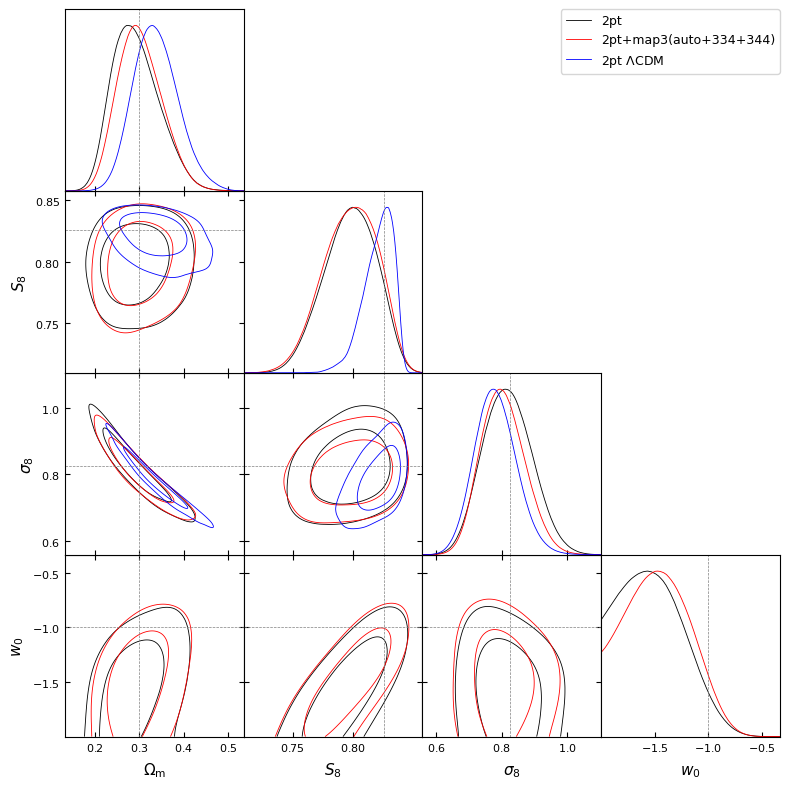

In [5]:
# COSMO
g = plots.get_single_plotter(ratio=1, width_inch=8)
g.triangle_plot([samples_2pt, samples_2pt_map3_auto_334_344, samples_2pt_lcdm], ['om', 's8', 'sig8', 'w0'], filled=False, \
    legend_labels=['2pt', '2pt+map3(auto+334+344)', '2pt $\Lambda$CDM'], legend_loc='upper right', 
    markers={'om': 0.3, 's8': 0.8256, 'sig8': 0.8256, 'w0':-1})
plt.show()

In [6]:
names = ['s8', 'om', 'w0']
samples_list = [samples_2pt, samples_2pt_map3_auto_334_344]
fom = np.array([utils.FoM_from_samples_names(s, names) for s in samples_list])
improve = fom/fom[0]

In [7]:
fom

array([4698.53481423, 4959.9529146 ])

In [8]:
improve

array([1.        , 1.05563822])